In [ ]:
import sys
import os
from pathlib import Path

# Setup paths for local data and modules
repo_root = Path.cwd()
print(f"Repository root: {repo_root}")

# Add module paths
if str(repo_root / "First_step_synthetic_data") not in sys.path:
    sys.path.insert(0, str(repo_root / "First_step_synthetic_data"))
if str(repo_root / "genetic_algo_synthetic_data") not in sys.path:
    sys.path.insert(0, str(repo_root / "genetic_algo_synthetic_data"))
if str(repo_root / "syntetic_data_gap_vrp_solver") not in sys.path:
    sys.path.insert(0, str(repo_root / "syntetic_data_gap_vrp_solver"))

print("Paths configured successfully")

In [ ]:
import json
from dataset import dataset_from_dict

# Path to dataset
dataset_path = repo_root / "genetic_algo_synthetic_data" / "dataset_sandbox_type2.json"
print(f"Dataset path: {dataset_path}")

In [ ]:
with open(dataset_path) as f:
    payload = json.load(f)

dataset = dataset_from_dict(payload)
dataset.validate()

print("Tasks:", len(dataset.tasks))
print("Agents:", len(dataset.fleet.agents))
print("Routes in source dataset:", len(dataset.routes))

Tasks: 18
Agents: 28
Routes in source dataset: 18


In [ ]:
!pip -q install numpy pandas scipy networkx matplotlib

In [ ]:
import simple_solver_milp
import genetic_solver_min
import gap_vrp_solver

print("MILP:", [x for x in dir(simple_solver_milp) if "solve" in x.lower() or "run" in x.lower()])
print("GA:", [x for x in dir(genetic_solver_min) if "solve" in x.lower() or "run" in x.lower()])
print("GAP+VRP:", [x for x in dir(gap_vrp_solver) if "solve" in x.lower() or "run" in x.lower()])

MILP: ['solve_sandbox_milp']
GA: ['MultiDaySandboxRunner', 'core_solver']
GAP+VRP: ['SolverResult', 'run_baseline_greedy', 'run_gap_vrp', 'solve_gap_lagrangean']


**MILP**

In [ ]:
from simple_solver_milp import solve_sandbox_milp

milp_result = solve_sandbox_milp(payload)
type(milp_result), milp_result

(tuple,
 (        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
          success: True
           status: 0
              fun: 138.72349699999998
                x: [ 0.000e+00  0.000e+00 ...  7.857e+01  0.000e+00]
   mip_node_count: 1
   mip_dual_bound: 138.72011600000016
          mip_gap: 2.437222296825302e-05,
     agent_id        depot                                        route_nodes  \
  0    AG_001   4110508936    [4110508936, 1399448460, 394906025, 4110508936]   
  1    AG_003   1573794598       [1573794598, 230306, 1867541742, 1573794598]   
  2    AG_006  10874111347   [10874111347, 364719227, 394906025, 10874111347]   
  3    AG_007   4110508936    [4110508936, 1603477050, 394906025, 4110508936]   
  4    AG_008   2003879579       [2003879579, 306596, 8294914306, 2003879579]   
  5    AG_009  11378629253  [11378629253, 3692844375, 394906025, 11378629253]   
  6    AG_010  11378629253  [11378629253, 2003879191, 10229332836, 1137862...   
  7    A

**GAP+VRP**

In [ ]:
import gap_vrp_solver

[name for name in dir(gap_vrp_solver) if "solve" in name.lower()]

['SolverResult', 'solve_gap_lagrangean']

In [ ]:
def run_gap_vrp(payload):
    dataset = dataset_from_dict(payload)

    graph = gvs.core.build_nx_graph(dataset)
    cache = {}

    agent_depots = payload["metadata"]["agent_depots"]

    states = []
    for agent in dataset.fleet.agents.values():
        depot = agent_depots[agent.agent_id]

        states.append(gvs.core.AgentState(
            agent_id=agent.agent_id,
            vehicle_type=agent.vehicle_type,
            capacity_tons=agent.capacity_tons,
            is_compact=agent.is_compact,
            depot_node=depot,
            current_node=depot,
            task_ids=[]
        ))

    result = gvs.solve_gap_lagrangean(
        states=states,
        dataset=dataset,
        graph=graph,
        cache=cache,
        tasks = dataset.tasks
    )

    return result

In [ ]:
gap_result = run_gap_vrp(payload)

gap_result

{'AG_001': [],
 'AG_002': [Task(task_id='TASK_0041', source_node_id='2003879191', destination_node_id='10229332836', container_type='Type2', mass_tons=2.6, periodicity='P1')],
 'AG_003': [Task(task_id='TASK_0026', source_node_id='1570463096', destination_node_id='1867541742', container_type='Type2', mass_tons=3.71, periodicity='P2'),
  Task(task_id='TASK_0024', source_node_id='5000329624', destination_node_id='10229332836', container_type='Type2', mass_tons=3.19, periodicity='P1')],
 'AG_004': [Task(task_id='TASK_0027', source_node_id='306596', destination_node_id='8294914306', container_type='Type2', mass_tons=4.48, periodicity='P3'),
  Task(task_id='TASK_0018', source_node_id='308181', destination_node_id='8294914306', container_type='Type2', mass_tons=3.61, periodicity='P1'),
  Task(task_id='TASK_0044', source_node_id='8087603', destination_node_id='1867541742', container_type='Type2', mass_tons=2.84, periodicity='P1'),
  Task(task_id='TASK_0039', source_node_id='1573813702', destin

**Genetic Algorithm**

In [ ]:
import genetic_solver_min

[name for name in dir(genetic_solver_min) if "solve" in name.lower() or "run" in name.lower()]

['MultiDaySandboxRunner', 'core_solver']

In [ ]:
from genetic_solver_min import MultiDaySandboxRunner

output_root = repo_root / "notebook_outputs"
output_root.mkdir(exist_ok=True)

runner = MultiDaySandboxRunner(
    dataset_path,
    output_root=output_root
)

In [ ]:
ga_result = runner.run(
    days=1,
    seed=42,
    mass_noise=0.0
)

ga_result

[DayResult(day_index=1, solver_status='feasible', assigned_routes=18, unassigned_tasks=0, active_agents=14, transport_work_ton_km=148.075, all_checks_ok=True, output_dir=PosixPath('/content/output/day_001'))]

In [ ]:
if isinstance(ga_result, list):
    ga_result = ga_result[0]

In [ ]:
ga_metrics = {
    "method": "Genetic",
    "assigned_routes": ga_result.assigned_routes,
    "unassigned_tasks": ga_result.unassigned_tasks,
    "active_agents": ga_result.active_agents,
    "ton_km": ga_result.transport_work_ton_km,
}

ga_metrics

{'method': 'Genetic',
 'assigned_routes': 18,
 'unassigned_tasks': 0,
 'active_agents': 14,
 'ton_km': 148.075}

In [ ]:
def extract_metrics(result, name):
    def get_value(obj, key, default=None):
        if isinstance(obj, dict):
            return obj.get(key, default)
        return getattr(obj, key, default)

    return {
        "method": name,
        "assigned_routes": get_value(result, "assigned_routes", get_value(result, "n_assigned")),
        "unassigned_tasks": get_value(result, "unassigned_tasks", get_value(result, "n_unassigned")),
        "active_agents": get_value(result, "active_agents"),
        "ton_km": get_value(result, "transport_work_ton_km"),
    }

In [ ]:
gap_metrics = {
    "method": "GAP+VRP",
    "assigned_routes": getattr(gap_result, "assigned_routes", getattr(gap_result, "n_assigned", None)),
    "unassigned_tasks": getattr(gap_result, "unassigned_tasks", getattr(gap_result, "n_unassigned", None)),
    "active_agents": getattr(gap_result, "active_agents", None),
    "ton_km": getattr(gap_result, "transport_work_ton_km", None),
}

gap_metrics

{'method': 'GAP+VRP',
 'assigned_routes': None,
 'unassigned_tasks': None,
 'active_agents': None,
 'ton_km': None}

In [ ]:
print("MILP:", milp_result)
print("\nGAP:", gap_result)

MILP: (        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 138.72349699999998
              x: [ 0.000e+00  0.000e+00 ...  7.857e+01  0.000e+00]
 mip_node_count: 1
 mip_dual_bound: 138.72011600000016
        mip_gap: 2.437222296825302e-05,    agent_id        depot                                        route_nodes  \
0    AG_001   4110508936    [4110508936, 1399448460, 394906025, 4110508936]   
1    AG_003   1573794598       [1573794598, 230306, 1867541742, 1573794598]   
2    AG_006  10874111347   [10874111347, 364719227, 394906025, 10874111347]   
3    AG_007   4110508936    [4110508936, 1603477050, 394906025, 4110508936]   
4    AG_008   2003879579       [2003879579, 306596, 8294914306, 2003879579]   
5    AG_009  11378629253  [11378629253, 3692844375, 394906025, 11378629253]   
6    AG_010  11378629253  [11378629253, 2003879191, 10229332836, 1137862...   
7    AG_011  11378629253  [11378629253, 3

In [ ]:
milp_df = milp_result[1]

milp_metrics = {
    "method": "MILP",
    "assigned_routes": len(milp_df),
    "unassigned_tasks": 0,
    "active_agents": milp_df["agent_id"].nunique(),
    "ton_km": milp_df["ton_km"].sum(),
}

milp_metrics

{'method': 'MILP',
 'assigned_routes': 17,
 'unassigned_tasks': 0,
 'active_agents': 17,
 'ton_km': np.float64(138.723497)}

In [ ]:
assigned = sum(len(tasks) for tasks in gap_result.values())

active = sum(1 for tasks in gap_result.values() if len(tasks) > 0)

gap_metrics = {
    "method": "GAP+VRP",
    "assigned_routes": assigned,
    "unassigned_tasks": len(dataset.tasks) - assigned,
    "active_agents": active,
    "ton_km": None,
}

gap_metrics

{'method': 'GAP+VRP',
 'assigned_routes': 18,
 'unassigned_tasks': 0,
 'active_agents': 7,
 'ton_km': None}

**Comparing metrics**

In [ ]:
results = [
    milp_metrics,
    gap_metrics,
    ga_metrics
]

import pandas as pd
df = pd.DataFrame(results)
df

,method,assigned_routes,unassigned_tasks,active_agents,ton_km
0,MILP,17,0,17,138.723497
1,GAP+VRP,18,0,7,NaN
2,Genetic,18,0,14,148.075000


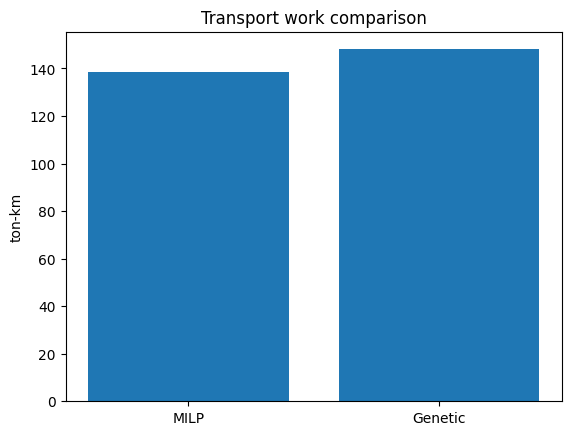

In [ ]:
df_plot = df.dropna()

import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_plot["method"], df_plot["ton_km"])
plt.title("Transport work comparison")
plt.ylabel("ton-km")
plt.show()